# Reproducing Figure 1 from Rubanenko et al.

This notebook attempts to reproduce Figure 1 from the Rubanenko paper using the provided `moon_data.csv` crater catalog.

In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt

# Add the project root to the Python path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from crater_analysis.io import read_crater_locations
from crater_analysis.plotting import plot_depth_diameter_vs_latitude
from crater_analysis.analysis import filter_craters

# Load the crater data
crater_data = read_crater_locations('../data/catalogs/moon_data.csv')

# The paper focuses on south polar craters, so let's filter for that
# The abstract mentions craters poleward of 80°S
south_polar_craters = filter_craters(crater_data, pole='south', lat_threshold=60, circ_threshold=0.85, lat_col='lat')
north_polar_craters = filter_craters(crater_data, pole='north', lat_threshold=60, circ_threshold=0.85, lat_col='lat')

south_polar_craters.head()

Successfully read 11228 crater locations from ../data/catalogs/moon_data.csv
Filtered to 3694 craters matching criteria.
Filtered to 3248 craters matching criteria.


,lat,lon,depth_m,diameter_m,dD,pf_slope,ef_slope,circ,test
1,-89.29,-58.92,280.87,4346.1,0.064626,0.10278,0.068158,0.94840,0
2,-89.28,-122.70,390.36,2920.5,0.133660,0.16646,0.148440,0.97030,0
3,-89.24,-17.13,610.35,5055.5,0.120730,0.23108,0.086901,0.94002,0
4,-89.21,74.19,501.35,7027.3,0.071343,0.13423,0.189500,0.88205,0
5,-89.19,28.02,590.28,3860.9,0.152890,0.22416,0.337320,0.94081,0


## Plot 1: Depth/Diameter Ratio vs. Latitude

This is a common analysis to see if crater morphology changes with latitude, possibly due to different material properties or modification processes.

(0.03, 0.2)

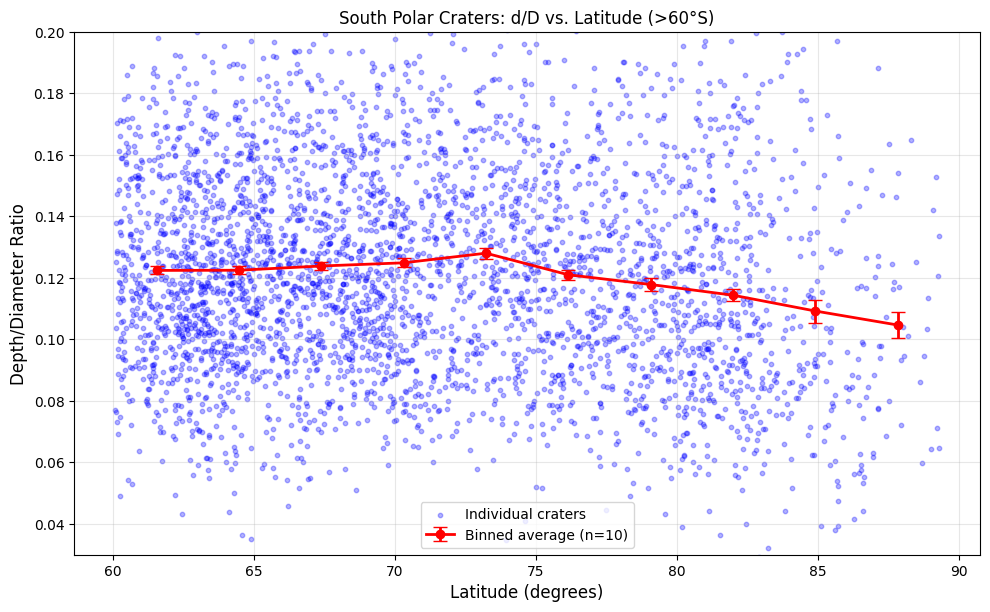

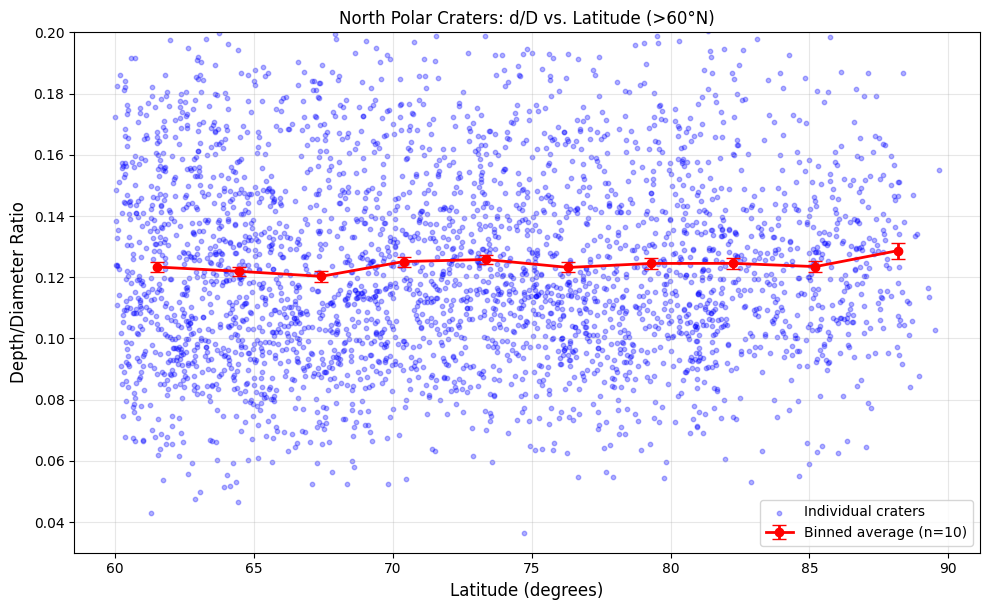

In [5]:


fig1, ax1 = plot_depth_diameter_vs_latitude(
    south_polar_craters, 
    bins=10, 
    show_scatter=True, 
    show_binned=True
)
ax1.set_title('South Polar Craters: d/D vs. Latitude (>60°S)')
ax1.set_ylim(0.03, 0.2)

fig2, ax2 = plot_depth_diameter_vs_latitude(
    north_polar_craters, 
    bins=10, 
    show_scatter=True, 
    show_binned=True
)
ax2.set_title('North Polar Craters: d/D vs. Latitude (>60°N)')
ax2.set_ylim(0.03, 0.2)

## Plot 2: Crater Wall Slopes vs. Latitude

This plot investigates the asymmetry in crater slopes. In polar regions, pole-facing slopes receive less sunlight than equator-facing slopes, which can affect ice stability and erosion.

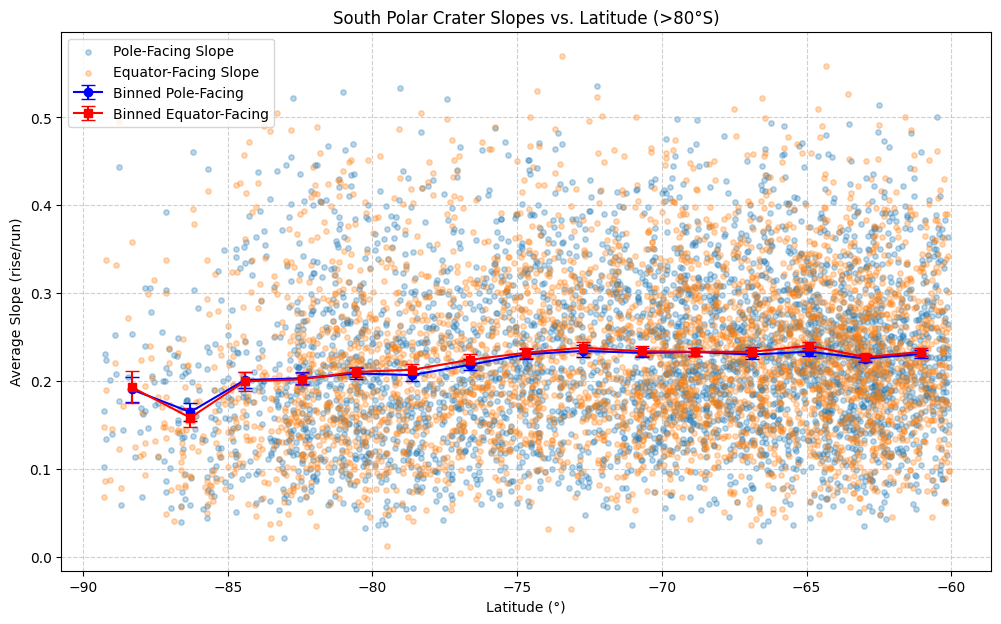

In [5]:
import numpy as np

fig2, ax2 = plt.subplots(figsize=(12, 7))

# Plot individual data points
ax2.scatter(south_polar_craters['lat'], south_polar_craters['pf_slope'], alpha=0.3, s=15, label='Pole-Facing Slope')
ax2.scatter(south_polar_craters['lat'], south_polar_craters['ef_slope'], alpha=0.3, s=15, label='Equator-Facing Slope')

# Calculate and plot binned averages
bins = 15
lat_bins = pd.cut(south_polar_craters['lat'], bins=bins)
binned_data = south_polar_craters.groupby(lat_bins, observed=False).agg(
    lat_mean=('lat', 'mean'),
    pf_slope_mean=('pf_slope', 'mean'),
    pf_slope_std=('pf_slope', 'std'),
    pf_slope_count=('pf_slope', 'count'),
    ef_slope_mean=('ef_slope', 'mean'),
    ef_slope_std=('ef_slope', 'std'),
    ef_slope_count=('ef_slope', 'count')
).dropna()

# Calculate standard error of the mean (SEM = std / sqrt(n))
binned_data['pf_slope_sem'] = binned_data['pf_slope_std'] / np.sqrt(binned_data['pf_slope_count'])
binned_data['ef_slope_sem'] = binned_data['ef_slope_std'] / np.sqrt(binned_data['ef_slope_count'])

ax2.errorbar(binned_data['lat_mean'], binned_data['pf_slope_mean'], yerr=binned_data['pf_slope_sem'], fmt='-o', color='blue', capsize=5, label='Binned Pole-Facing')
ax2.errorbar(binned_data['lat_mean'], binned_data['ef_slope_mean'], yerr=binned_data['ef_slope_sem'], fmt='-s', color='red', capsize=5, label='Binned Equator-Facing')

ax2.set_xlabel('Latitude (°)')
ax2.set_ylabel('Average Slope (rise/run)')
ax2.set_title('South Polar Crater Slopes vs. Latitude (>80°S)')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

plt.show()